In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from helpers.geometry_map import make_geometry_map, build_dist_tree_from_map

In [5]:
iid = 1

path_to_data = f"/pscratch/sd/r/rmastand/muon_collider/npys/nuGun_pT_0_50/reco_h5/nuGun_pT_0_50_reco_{iid}.h5"

df = pd.read_hdf(path_to_data, key="df") 
print(df)



          event                    collection      Edep         t           x  \
0             1  InnerTrackerBarrelCollection  0.000289  1.055107  126.968500   
1             1  InnerTrackerBarrelCollection  0.000055  1.048633  126.968500   
2             1  InnerTrackerBarrelCollection  0.000010  1.024815  127.000522   
3             1  InnerTrackerBarrelCollection  0.000082  2.065296 -267.875769   
4             1  InnerTrackerBarrelCollection  0.000045  2.078346  212.793068   
...         ...                           ...       ...       ...         ...   
25202311      1        VertexEndcapCollection  0.000017  0.779050  -33.089746   
25202312      1        VertexEndcapCollection  0.000012  0.486435  -52.221875   
25202313      1        VertexEndcapCollection  0.000017  0.470859  -51.408205   
25202314      1        VertexEndcapCollection  0.000015  0.330662  -35.975104   
25202315      1        VertexEndcapCollection  0.000016  0.314854  -33.627993   

                   y       

In [ ]:
NUM_R0WS = 26_580_643

InnerTrackerBarrelCollection
1494250
[126.9709787  126.96961082 129.93097645 ... 129.4912833  129.96335352
 130.17752831]
126.96756251452243 130.34066093764122


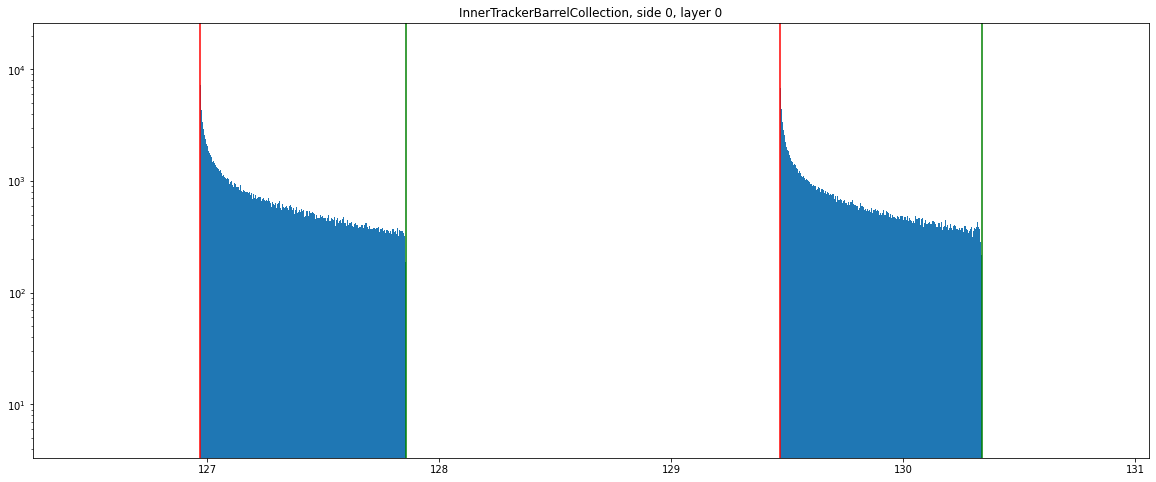

1144867
[339.96914624 342.48167175 342.46891313 ... 340.02932371 339.98961481
 340.21123475]
339.9675188344099 342.7997755998354


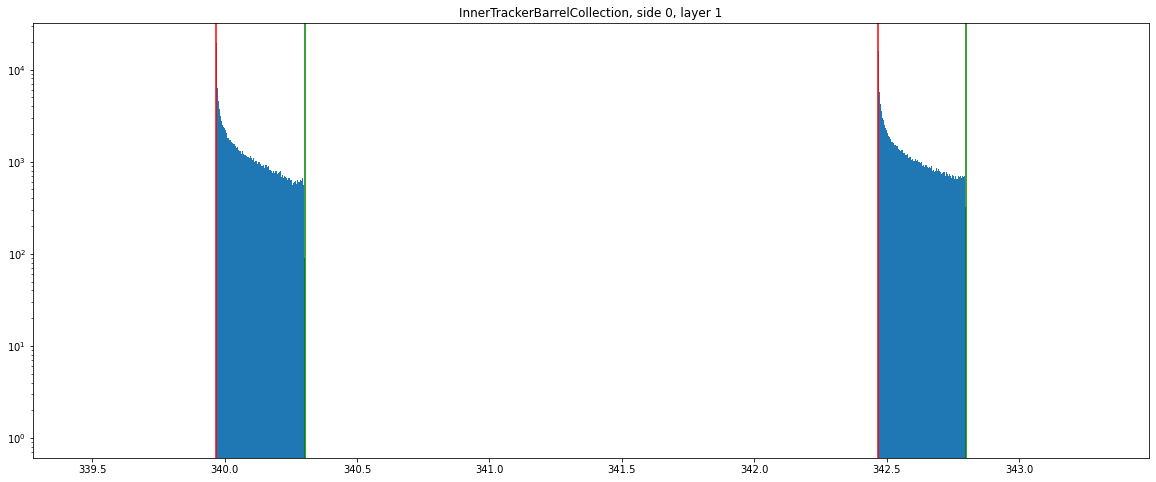

1127250
[554.08167253 556.65337719 554.04415274 ... 556.65230493 553.96938687
 553.97582246]
553.9675275495406 556.6728543439814


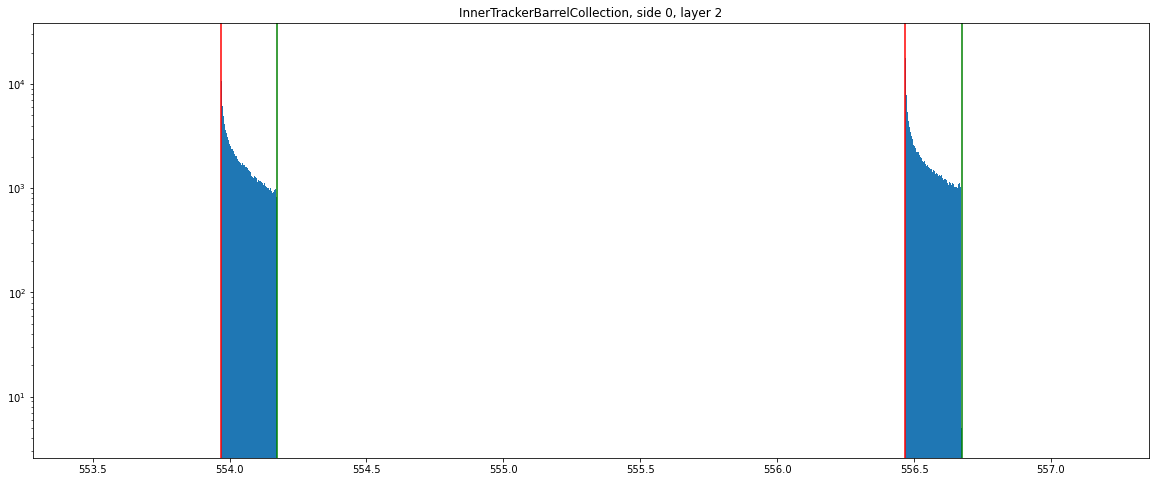

OuterTrackerBarrelCollection
1288321
[817.14854868 817.15915176 817.1485677  ... 817.14885099 817.15823409
 817.19484799]
817.1475421734136 822.7870152077246


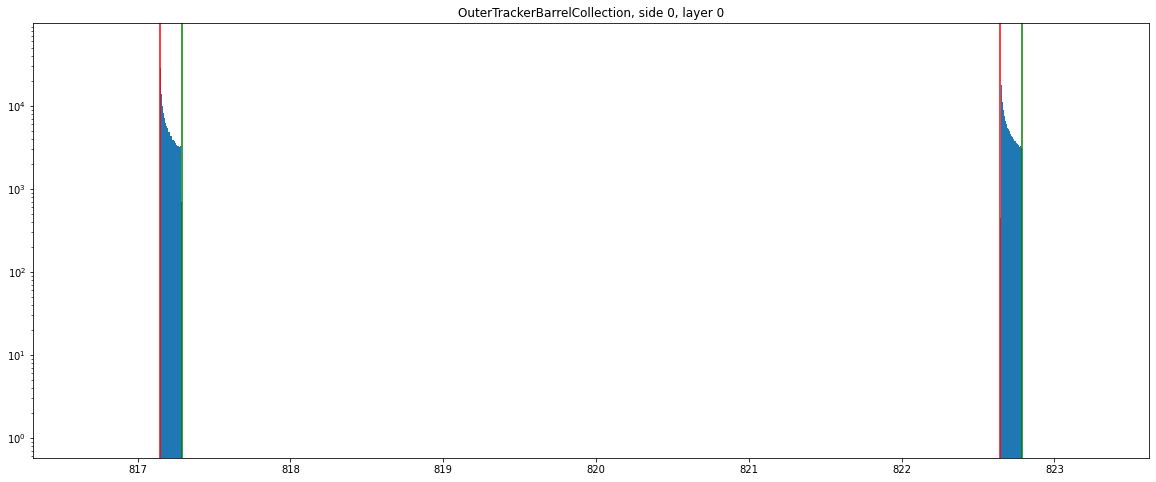

1057682
[1151.22014533 1151.16617584 1151.16510155 ... 1156.69624598 1156.70465797
 1156.6954905 ]
1151.147506236682 1156.7472942017944


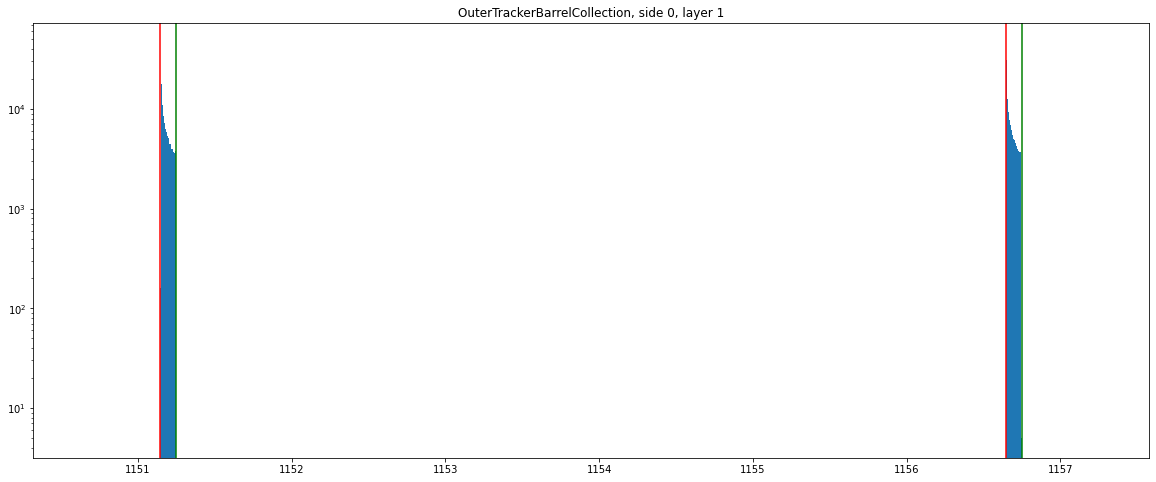

798535
[1493.39774823 1493.36251997 1487.86277585 ... 1487.85496641 1487.85710523
 1487.86590657]
1487.8505085570528 1493.4281768195065


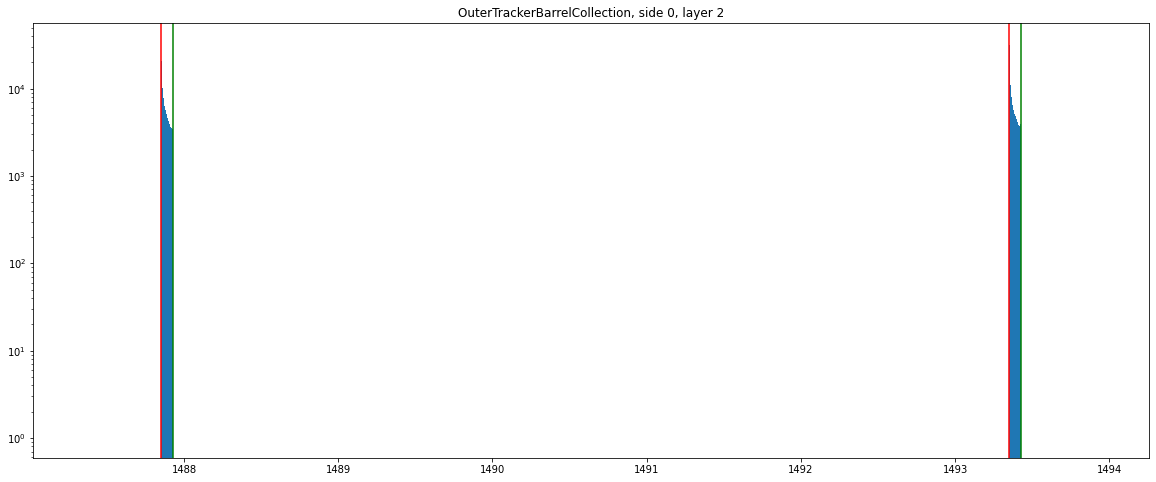

VertexBarrelCollection
726379
[30.16971498 30.19708043 30.18671927 ... 30.16661118 31.04023955
 30.47288495]
30.1641428193451 31.339127717259284


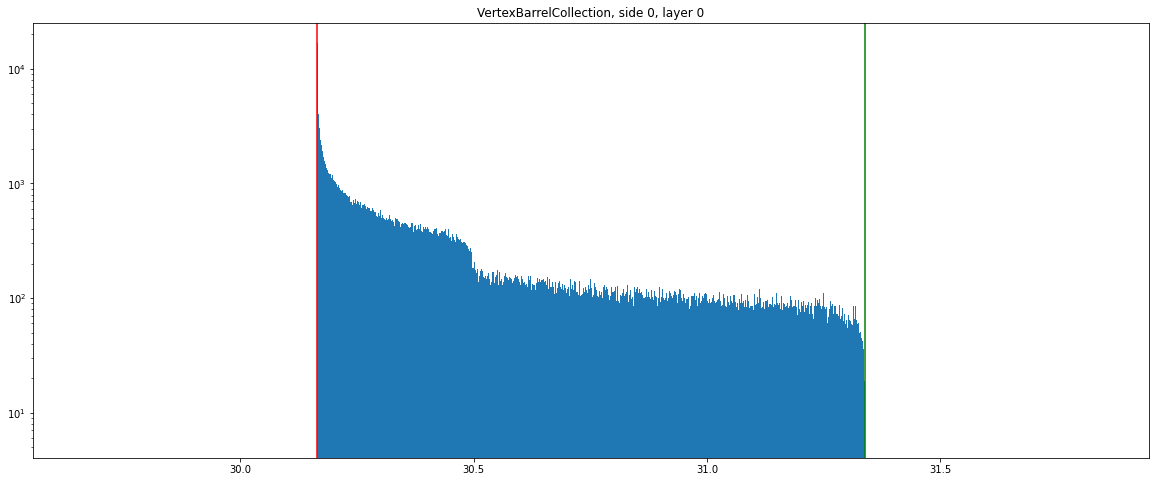

520768
[32.22454347 32.2157905  32.22912689 ... 32.37328967 32.23260786
 32.85266933]
32.214078886817006 33.317769789197584


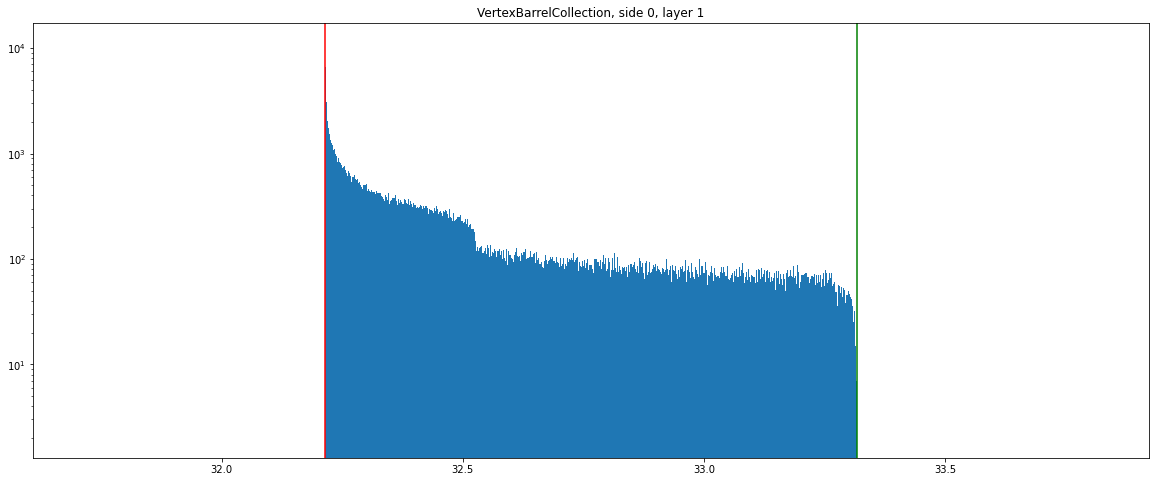

224354
[51.17303383 51.16503044 51.17078801 ... 51.17261919 51.17218488
 51.55665982]
51.16406031838949 52.91497103862363


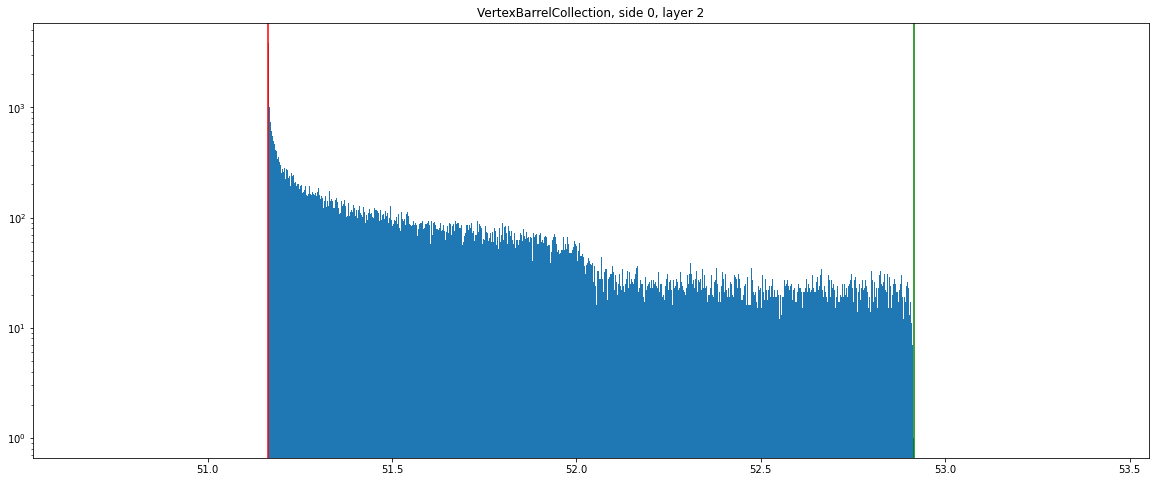

215664
[74.19782503 74.60238742 74.57244455 ... 74.27367204 74.62048557
 74.67969528]
74.1642462035724 75.47494655912234


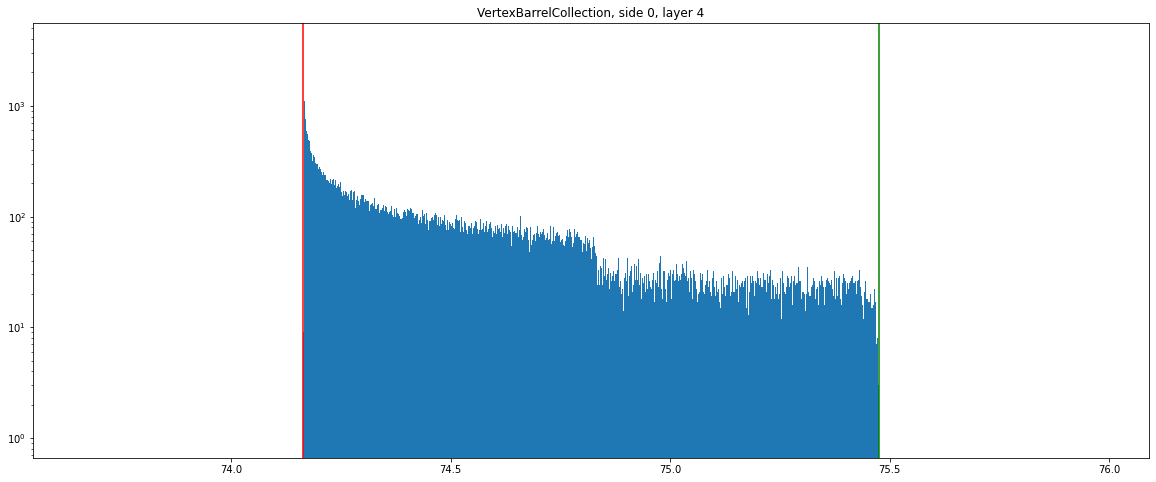

224133
[102.55818725 102.64736932 102.90726039 ... 102.16520789 102.16549353
 102.58238681]
102.16446271219452 103.12002799807073


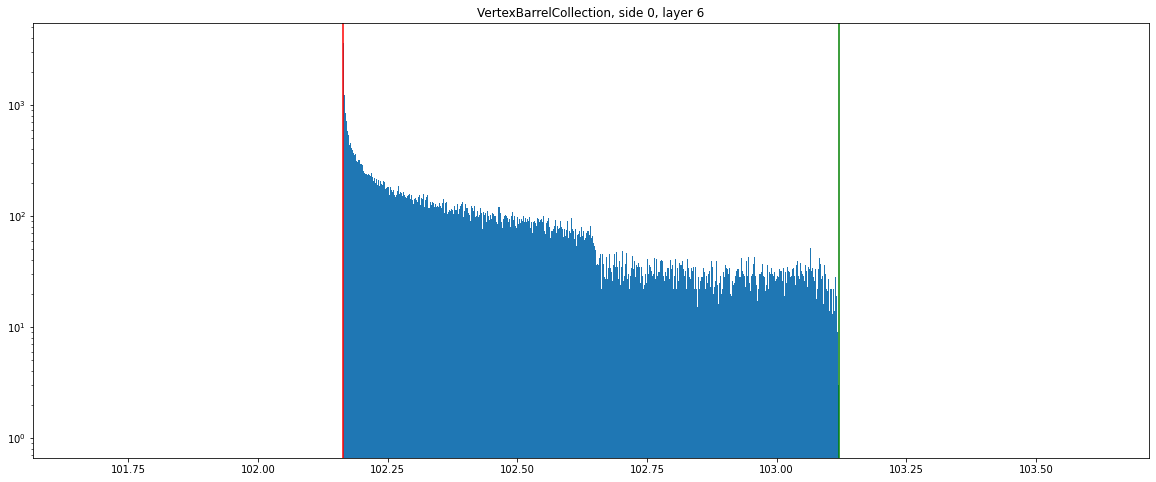

{'InnerTrackerBarrelCollection': {(0, 0): {'starts': [126.96707025599089, 129.46723334726383], 'stops': [127.85848599777086, 130.34115319617277]}, (0, 1): {'starts': [339.96734508187086, 342.46724292384977], 'stops': [340.30311792909157, 342.7999493523744]}, (0, 2): {'starts': [553.9671055170247, 556.4672189952502], 'stops': [554.1739041118735, 556.6732763764973]}}, 'OuterTrackerBarrelCollection': {(0, 0): {'starts': [817.1469304232438, 822.64684197257], 'stops': [817.2890435688072, 822.7876269578944]}, (0, 1): {'starts': [1151.1465500156003, 1156.6465933568002], 'stops': [1151.2482070816761, 1156.748250422876]}, (0, 2): {'starts': [1487.849195548745, 1493.349226222291], 'stops': [1487.9294591542682, 1493.4294898278142]}}, 'VertexBarrelCollection': {(0, 0): {'starts': [30.164054331188147], 'stops': [31.339216205416236]}, (0, 1): {'starts': [32.21401583261179], 'stops': [33.3178328434028]}, (0, 2): {'starts': [51.16372563824798], 'stops': [52.91530571876513]}, (0, 4): {'starts': [74.163

In [14]:

collections = [
    "InnerTrackerBarrelCollection",
    #"InnerTrackerEndcapCollection",
    "OuterTrackerBarrelCollection",     
    #"OuterTrackerEndcapCollection",  
    "VertexBarrelCollection",   
    #"VertexEndcapCollection",
]



results_dir = {}

for col_name in collections:

    df_col =  df[df["collection"] == col_name]

    results_dir[col_name] = {}

    print(col_name)

    #layer_var = df_col[["x"]].to_numpy().reshape(-1,)
    layer_var = np.sqrt(df_col[["x"]].to_numpy().reshape(-1,)**2 +  df_col[["y"]].to_numpy().reshape(-1,)**2)
    side = df_col[["side"]].to_numpy().reshape(-1,)
    layer  = df_col[["layer"]].to_numpy().reshape(-1,)
    inside_bounds  = df_col[["inside_bounds"]].to_numpy().reshape(-1,)


    for s in set(list(side)):
        for l in set(list(layer)):

            results_dir[col_name][s,l] = {"starts":[], "stops":[]}

            starts, stops = [], []
            mask = (side == s) & (layer == l) & inside_bounds

            

            loc_layer_var = layer_var[mask]

            layer_bounds = np.linspace(loc_layer_var.min()-0.5, loc_layer_var.max()+0.5, 5000)

            plt.figure(figsize=(20, 8))
            n, _, _  =  plt.hist(loc_layer_var, bins = layer_bounds)
            plt.title(f"{col_name}, side {s}, layer {l}")
            

            for i in range(len(n)-1):
                if n[i] == 0 and n[i+1] > 0:
                    results_dir[col_name][s,l]["starts"].append(layer_bounds[i+1])
                    plt.axvline(layer_bounds[i+1], color = "r")
                if n[i] > 0 and n[i+1] == 0:
                    results_dir[col_name][s,l]["stops"].append(layer_bounds[i+1])
                    plt.axvline(layer_bounds[i+1], color = "g")

            plt.yscale("log")

            plt.show()



print(results_dir)
 

In [15]:
print(results_dir)

{'InnerTrackerBarrelCollection': {(0, 0): {'starts': [126.96707025599089, 129.46723334726383], 'stops': [127.85848599777086, 130.34115319617277]}, (0, 1): {'starts': [339.96734508187086, 342.46724292384977], 'stops': [340.30311792909157, 342.7999493523744]}, (0, 2): {'starts': [553.9671055170247, 556.4672189952502], 'stops': [554.1739041118735, 556.6732763764973]}}, 'OuterTrackerBarrelCollection': {(0, 0): {'starts': [817.1469304232438, 822.64684197257], 'stops': [817.2890435688072, 822.7876269578944]}, (0, 1): {'starts': [1151.1465500156003, 1156.6465933568002], 'stops': [1151.2482070816761, 1156.748250422876]}, (0, 2): {'starts': [1487.849195548745, 1493.349226222291], 'stops': [1487.9294591542682, 1493.4294898278142]}}, 'VertexBarrelCollection': {(0, 0): {'starts': [30.164054331188147], 'stops': [31.339216205416236]}, (0, 1): {'starts': [32.21401583261179], 'stops': [33.3178328434028]}, (0, 2): {'starts': [51.16372563824798], 'stops': [52.91530571876513]}, (0, 4): {'starts': [74.163

In [ ]:
col_name = "VertexEndcapCollection"

df_col =  df[df["collection"] == col_name]


system =  df_col[["system"]].to_numpy()
side =  df_col[["side"]].to_numpy()
layer =  df_col[["layer"]].to_numpy()
module =  df_col[["module"]].to_numpy()

r = np.sqrt(df_col[["x"]].to_numpy()**2 + df_col[["y"]].to_numpy()**2)
phi = np.arctan2(df_col[["y"]].to_numpy(), df_col[["x"]].to_numpy())
z = df_col[["z"]].to_numpy()
Edep = df_col[["Edep"]].to_numpy()
t = df_col[["t"]].to_numpy()

print(set(list(layer.flatten())))

fig, ax = plt.subplots(1, 5, figsize = (20, 6))

ax[0].hist(r, bins = np.linspace(np.min(r), np.max(r), 100), histtype = "step", label = "without mask", density = True  )
ax[0].set_xlabel("r [mm]")
ax[1].hist(phi, bins = np.linspace(np.min(phi), np.max(phi), 100), range = (-np.pi, np.pi), histtype = "step", label = "without mask", density = True  )
ax[1].set_xlabel("phi [rad]")
ax[2].hist(z, bins = np.linspace(np.min(z), np.max(z), 100), range = (-4000, 4000), histtype = "step", label = "without mask", density = True  )
ax[2].set_xlabel("z [mm]")
ax[3].hist(Edep, bins = np.linspace(np.min(Edep), np.max(Edep), 100), histtype = "step", label = "without mask", density = True  )
ax[3].set_xlabel("Edep [GeV]")
ax[4].hist(t, bins = np.linspace(np.min(t), np.max(t), 100), histtype = "step", label = "without mask", density = True  )
ax[4].set_xlabel("t [ns]")

for i in range(len(set(list(layer.flatten())))):

    mask = (layer == i) 
    ax[0].hist(r[mask], bins = np.linspace(np.min(r), np.max(r), 100), range = (0, 2000), histtype = "step", label = f"system {i}", density = True  )
    ax[1].hist(phi[mask], bins = np.linspace(np.min(phi), np.max(phi), 100), range = (-np.pi, np.pi), histtype = "step", label = f"system {i}", density = True  )
    ax[2].hist(z[mask], bins = np.linspace(np.min(z), np.max(z), 100), range = (-4000, 4000), histtype = "step", label = f"system {i}", density = True  )
    ax[3].hist(Edep[mask], bins = np.linspace(np.min(Edep), np.max(Edep), 100), histtype = "step", label = f"system {i}", density = True  )
    ax[4].hist(t[mask], bins = np.linspace(np.min(t), np.max(t), 100), histtype = "step", label = f"system {i}", density = True  )


for i in range(5):
    ax[i].set_yscale("log")
ax[4].legend(loc = (1, 0))

plt.suptitle(col_name)

plt.show()


In [16]:
collections = [
    "InnerTrackerBarrelCollection",
    "InnerTrackerEndcapCollection",
    "OuterTrackerBarrelCollection",     
    "OuterTrackerEndcapCollection",  
    "VertexBarrelCollection",   
    "VertexEndcapCollection",
]

for col in collections:
    
    df_col = df[df["collection"] == col]
    print(len(df_col))
    df_col = df_col[df_col["inside_bounds"] == True]
    print(col, len(df_col))



    df_col_selected = df_col[["Edep", "x", "y", "z", "t", "side", "layer"]].to_numpy()

    np.save(f"/pscratch/sd/r/rmastand/muon_collider/npys/nuGun_pT_0_50/{col}_SimTrackerHit_conditional_reco_{iid}.npy", df_col_selected)

6363622
InnerTrackerBarrelCollection 3766367
2233710
InnerTrackerEndcapCollection 1523625
6505022
OuterTrackerBarrelCollection 3144538
2707307
OuterTrackerEndcapCollection 1403849
2401650
VertexBarrelCollection 1911298
4991005
VertexEndcapCollection 3817087


# Make geometry map

In [ ]:
geo_map_path = "/pscratch/sd/r/rmastand/muon_collider/geometry_map.txt"

# make_geometry_map(
#     df,
#     collections,
#     geo_map_path,
#     num_events_per_col=1_000_000,
    
# )

In [ ]:
tree_map, cellid_layer_map = build_dist_tree_from_map(geo_map_path)

In [ ]:
from tqdm import tqdm

In [ ]:
col_hits_per_layer = {col:{} for col in collections}


dists = []
for i in tqdm(range(0, 26580643, 100)):

    
    event = df.iloc[i]
    col_name = event["collection"]
    layer_truth = event["layer"]
    x_truth, y_truth, z_truth = event["x"], event["y"], event["z"]

    dist, idx = tree_map[col_name].query([x_truth, y_truth, z_truth])
 
    cell_id_returned, layer_returned = cellid_layer_map[col_name][idx]

    if layer_returned != layer_truth:
        print('ERROR', event["collection"], layer_returned, layer_truth, dist)


    try:
        col_hits_per_layer[col_name][layer_returned] += 1
    except KeyError:
        col_hits_per_layer[col_name][layer_returned] = 1
    
        
    dists.append(dist)

    
    

In [ ]:
plt.figure()
plt.hist(dists, bins = 100)
plt.show()

# Flow

In [ ]:
col_hits_per_layer = {col: {} for col in collections}
dists = []

for col_name in collections:

    small_id = ''.join([c for c in col_name if c.isupper()])
    print(small_id)

    flow_samples = np.load(
        f"/pscratch/sd/r/rmastand/muon_collider/zuko_outputs/NCSF/{small_id}_M_4096_rphi/flow_samples.npy"
    )

    # -----------------------------
    # 1. Extract coordinates
    # -----------------------------
    points = flow_samples[:, 1:4]   # shape (N, 3)

    # -----------------------------
    # 2. Mask out NaNs / infs
    # -----------------------------
    valid_mask = np.isfinite(points).all(axis=1)
    points_valid = points[valid_mask]

    # Skip if nothing valid
    if len(points_valid) == 0:
        continue

    # -----------------------------
    # 3. Batch KDTree query
    # -----------------------------
    dists_batch, idx_batch = tree_map[col_name].query(points_valid)

    # -----------------------------
    # 4. Remove invalid KDTree hits
    # -----------------------------
    valid_idx_mask = idx_batch < len(cellid_layer_map[col_name])

    idx_batch = idx_batch[valid_idx_mask]
    dists_batch = dists_batch[valid_idx_mask]

    # -----------------------------
    # 5. Map to (cell_id, layer)
    # -----------------------------
    cell_layer = cellid_layer_map[col_name][idx_batch]
    layers = cell_layer[:, 1]

    # -----------------------------
    # 6. Count hits per layer (vectorized)
    # -----------------------------
    unique_layers, counts = np.unique(layers, return_counts=True)

    for layer, count in zip(unique_layers, counts):
        col_hits_per_layer[col_name][layer] = (
            col_hits_per_layer[col_name].get(layer, 0) + count
        )

    # -----------------------------
    # 7. Collect distances
    # -----------------------------
    dists.append(dists_batch)

In [ ]:
print(col_hits_per_layer)

In [ ]:
collections_order = [
    'VertexBarrelCollection',
    'VertexEndcapCollection',
    'InnerTrackerBarrelCollection',
    'InnerTrackerEndcapCollection',
    'OuterTrackerBarrelCollection',
    'OuterTrackerEndcapCollection'
]

# Prepare x positions
width = 0.1  # width of each bar
x_offsets = np.arange(0, len(col_hits_per_layer[collections_order[0]]))  # base positions for first collection

fig, ax = plt.subplots(figsize=(12, 6))

# Keep track of total x positions
x_pos = 0
x_labels = []
x_ticks = []

for coll in collections_order:
    layers = sorted(col_hits_per_layer[coll].keys())  # sort layers numerically
    counts = [col_hits_per_layer[coll][l] for l in layers]

    # compute positions for this collection
    positions = x_pos + np.arange(len(layers))
    ax.bar(positions, counts, width=0.8, label=coll)
    
    # collect labels and ticks
    x_labels.extend([f"{l}" for l in layers])
    x_ticks.extend(positions)
    
    # update x_pos for next collection to avoid overlap
    x_pos = positions[-1] + 1  # add gap between collections

ax.set_xticks(x_ticks)
ax.set_xticklabels(x_labels, rotation=45, ha='right')
ax.set_ylabel("Number of hits")
ax.set_title("Hits per Detector Layer")
ax.legend()
plt.tight_layout()
plt.yscale("log")
plt.savefig("figures/hits_per_detector_layer.png")
plt.show()